# Test RPC and Vecchia approximation for kernel ridge regression
We want to use the preconditioner for the gaussian process code, but for now, just test out how it works on some basic kernel ridge regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from functions import RandomlyPivotedCholesky, RidgewPartialChol
import math

In [2]:
def RBF(x, y, theta):
    # theta[0] = sigma_f
    # theta[1] = l
    t = np.dot(x-y, x-y)
    out = theta[0]**2 * math.exp(-1/(2*theta[1]) * t)
    return out

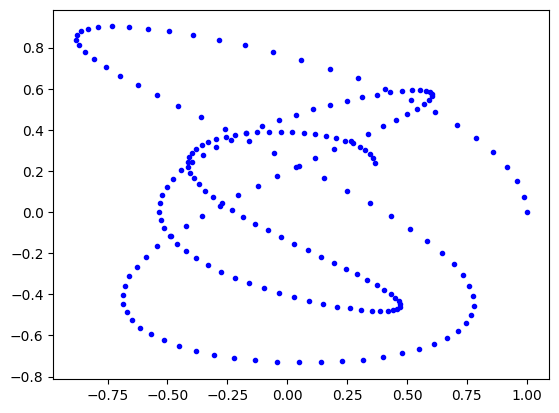

In [3]:
n = 200
t = np.linspace(0, 5, n)
x = np.cos(5*t)*np.exp(-t*0.2)
y = np.sin(3*t)*np.exp(-t*0.2)
fig1 = plt.figure()
plt.plot(x, y, 'b.')

In [4]:
X = np.vstack([x, y])
print(X.shape)
K = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        K[i,j] = RBF(X[:,i], X[:,j], [0.1, 0.3])

print(K)

(2, 200)
[[0.01       0.00990414 0.00961119 ... 0.00428295 0.00448635 0.00463856]
 [0.00990414 0.01       0.0098966  ... 0.00468025 0.00487491 0.00501155]
 [0.00961119 0.0098966  0.01       ... 0.00517669 0.0053585  0.00547571]
 ...
 [0.00428295 0.00468025 0.00517669 ... 0.01       0.00999029 0.00996382]
 [0.00448635 0.00487491 0.0053585  ... 0.00999029 0.01       0.00999131]
 [0.00463856 0.00501155 0.00547571 ... 0.00996382 0.00999131 0.01      ]]


In [9]:
I = RandomlyPivotedCholesky(K, 20)
print(I)
mu = 1e-4
x = RidgewPartialChol(mu, K, I, np.ones(n))
# print(x)
print((mu*np.eye(n) + K)@x)

[np.int64(184), np.int64(40), np.int64(167), np.int64(80), np.int64(102), np.int64(15), np.int64(132), np.int64(51), np.int64(158), np.int64(1), np.int64(62), np.int64(73), np.int64(33), np.int64(21), np.int64(59), np.int64(70), np.int64(87), np.int64(110), np.int64(11), np.int64(26)]
(20, 20)
[0.97115194 1.         1.02475798 1.04260636 1.05135323 1.04972775
 1.03812684 1.01959736 1.00022894 0.98774689 0.98784978 1.
 1.01621119 1.02512673 1.01927332 1.         0.97629406 0.95888005
 0.95437531 0.96307007 0.98040715 1.         1.01613981 1.02501396
 1.02490222 1.01595545 1.         0.98046695 0.96220494 0.9507133
 0.95041467 0.96221075 0.9816765  1.         1.0086965  1.00576912
 0.99794668 0.99528704 1.00137219 1.00796494 1.         0.96713432
 0.91205551 0.84940354 0.79755877 0.7700751  0.77163409 0.79891652
 0.8439891  0.89769964 0.95183668 1.         1.03769014 1.06216431
 1.07239715 1.06921435 1.05542456 1.03562819 1.01542194 1.
 0.99258645 0.99343554 1.         1.00826445 1.01455

In [6]:
Khat = K[:,I]@np.linalg.inv(K[np.ix_(I,I)])@K[I,:]
print(Khat.shape)
print(np.linalg.norm(K - Khat))
print(np.linalg.norm(K))

(200, 200)
0.001645494731435545
1.0048415997633078


In [7]:
L = K[:,I]
print(L.shape)
print(L[0,0])
print(K[0,I[0]])
U = K[np.ix_(I, I)]
print(U.shape)


(200, 20)
0.0012993490711434245
0.0012993490711434245
(20, 20)
